# Massachusetts GerryChain Ensemble Analysis

This notebook loads the cleaned Massachusetts file from `cleaning.ipynb`, rebuilds the connected dual graph using the saved added edges, runs ReCom ensembles, checks convergence by comparing 20,000 and 40,000 steps, and creates the final project figures.


In [1]:
# setup and imports
import os
import json
import time
import warnings
from functools import partial

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

import gerrychain
from gerrychain import Graph, GeographicPartition, constraints, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from gerrychain.constraints import contiguous
from gerrychain.metrics import polsby_popper

warnings.filterwarnings("ignore")

# paths made by cleaning.ipynb
DATA_DIR = "MA"
SHAPE_PATH = os.path.join(DATA_DIR, "MA.shp")
ADDED_EDGES_PATH = os.path.join(DATA_DIR, "MA_added_edges.csv")
CONFIG_PATH = "config.json"

for path in [SHAPE_PATH, CONFIG_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {path}. Run cleaning.ipynb first.")

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

DEM_COL_1 = cfg["DEM_COL_1"]
REP_COL_1 = cfg["REP_COL_1"]
DEM_COL_2 = cfg["DEM_COL_2"]
REP_COL_2 = cfg["REP_COL_2"]

print("Loaded config:", cfg)


Loaded config: {'DEM_COL_1': 'G24PREDHAR', 'REP_COL_1': 'G24PRERTRU', 'DEM_COL_2': 'G24USSDWAR', 'REP_COL_2': 'G24USSRDEA', 'snap_precision_used': 8, 'snap_precision_reason': 'Used snap_precision=8 because snap_precision=10 failed during smart_repair. The lower precision is a reasonable fallback for tiny boundary mismatches.', 'min_rook_length': 30}


In [2]:
# load graph and apply the added dual-graph edges saved by cleaning.ipynb
base_graph = Graph.from_file(
    SHAPE_PATH,
    adjacency="queen",
    cols_to_add=["TOTPOP", "CD", DEM_COL_1, REP_COL_1, DEM_COL_2, REP_COL_2],
)

temp_graph = nx.Graph(base_graph)

# coerce CSV node IDs back to the node type used by GerryChain/NetworkX
# usually these are integers, but this keeps the code safe if the graph uses strings later
def find_node_id(raw_value, graph):
    candidates = [raw_value]
    try:
        candidates.append(int(raw_value))
    except Exception:
        pass
    try:
        candidates.append(int(float(raw_value)))
    except Exception:
        pass
    candidates.append(str(raw_value))
    for candidate in candidates:
        if candidate in graph:
            return candidate
    raise KeyError(f"Could not match node {raw_value} to a graph node.")

if os.path.exists(ADDED_EDGES_PATH):
    added_edges_df = pd.read_csv(ADDED_EDGES_PATH)
    for _, row in added_edges_df.iterrows():
        u = find_node_id(row["u"], temp_graph)
        v = find_node_id(row["v"], temp_graph)
        temp_graph.add_edge(u, v)
    print("Applied saved manual dual-graph edges:", len(added_edges_df))
else:
    added_edges_df = pd.DataFrame(columns=["u", "v", "CD", "distance_m"])
    print("No added-edge CSV found. If the graph is disconnected, rerun cleaning.ipynb.")

ma_graph = gerrychain.Graph(temp_graph)

# matching GeoDataFrame for plotting and centroids
map_df = gpd.read_file(SHAPE_PATH)
map_df.index = list(ma_graph.nodes())

# make graph attributes consistent and numeric
for v in ma_graph.nodes():
    ma_graph.nodes[v]["CD"] = str(ma_graph.nodes[v]["CD"]).zfill(2)
    ma_graph.nodes[v]["TOTPOP"] = float(ma_graph.nodes[v].get("TOTPOP", 0) or 0)
    for col in [DEM_COL_1, REP_COL_1, DEM_COL_2, REP_COL_2]:
        ma_graph.nodes[v][col] = float(ma_graph.nodes[v].get(col, 0) or 0)
map_df["CD"] = map_df["CD"].astype(str).str.zfill(2)

print("Graph connected?", nx.is_connected(ma_graph))
print("Number of nodes:", len(ma_graph.nodes()))
print("Number of edges:", len(ma_graph.edges()))


Applied saved manual dual-graph edges: 7
Graph connected? True
Number of nodes: 2383
Number of edges: 6993


In [3]:
# build the initial partition from the enacted Congressional District assignment
initial_plan = {v: ma_graph.nodes[v]["CD"] for v in ma_graph.nodes()}
district_labels = sorted(set(initial_plan.values()))

total_population = sum(ma_graph.nodes[v]["TOTPOP"] for v in ma_graph.nodes())
num_districts = len(district_labels)
ideal_pop = total_population / num_districts
pop_tolerance = 0.02

elections = [
    Election("PRES24", {"Democratic": DEM_COL_1, "Republican": REP_COL_1}),
    Election("SEN24",  {"Democratic": DEM_COL_2, "Republican": REP_COL_2}),
]

my_updaters = {
    "cut_edges": cut_edges,
    "district population": Tally("TOTPOP", alias="district population"),
}
my_updaters.update({election.name: election for election in elections})

initial_partition = GeographicPartition(
    ma_graph,
    assignment=initial_plan,
    updaters=my_updaters,
)

print("district labels:", district_labels)
print("ideal population:", round(ideal_pop, 2))
print("population tolerance:", pop_tolerance)
print("initial partition contiguous?", contiguous(initial_partition))

for district_label in district_labels:
    district_nodes = [v for v in ma_graph.nodes() if initial_plan[v] == district_label]
    district_graph = ma_graph.subgraph(district_nodes)
    print(
        "district", district_label,
        "connected?", nx.is_connected(district_graph),
        "components:", nx.number_connected_components(district_graph),
    )


district labels: ['01', '02', '03', '04', '05', '06', '07', '08', '09']
ideal population: 781101.89
population tolerance: 0.02
initial partition contiguous? True
district 01 connected? True components: 1
district 02 connected? True components: 1
district 03 connected? True components: 1
district 04 connected? True components: 1
district 05 connected? True components: 1
district 06 connected? True components: 1
district 07 connected? True components: 1
district 08 connected? True components: 1
district 09 connected? True components: 1


## Parameter choices

The ReCom proposal uses the cleaned precinct graph, total population, and the current Congressional District assignment as the starting plan. The population tolerance is set to 2%, matching the class examples and keeping the districts close to equal population without making the chain too fragile. `node_repeats=2` gives ReCom one extra try when it searches for a balanced cut, which is helpful for a state like Massachusetts with many small precincts and island connections. The compactness bound is set to twice the enacted map's cut edges, so the chain cannot drift into extremely jagged maps, but it still has enough room to explore many reasonable alternatives. The notebook runs both 20,000 and 40,000 step versions and compares their histograms/running averages as the convergence check.


In [4]:
# functions and ReCom setup
def efficiency_gap(partition, election_key):
    results = partition[election_key]
    total_votes = 0
    wasted_dem = 0
    wasted_rep = 0

    dem_votes = results.votes("Democratic")
    rep_votes = results.votes("Republican")

    for i in range(len(dem_votes)):
        d_votes = dem_votes[i]
        r_votes = rep_votes[i]
        total = d_votes + r_votes
        if total == 0:
            continue

        total_votes += total
        threshold = total / 2 + 1

        if d_votes > r_votes:
            wasted_dem += d_votes - threshold
            wasted_rep += r_votes
        else:
            wasted_rep += r_votes - threshold
            wasted_dem += d_votes

    return (wasted_dem - wasted_rep) / total_votes


rw_proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=pop_tolerance,
    node_repeats=2,
)

population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition,
    pop_tolerance,
    pop_key="district population",
)

compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2 * len(initial_partition["cut_edges"]),
)


def empty_results(total_steps):
    return {
        "total_steps": total_steps,
        "cutedges": [],
        "PRES24": {"eg": [], "dem_won": [], "margins": []},
        "SEN24": {"eg": [], "dem_won": [], "margins": []},
    }


def record_partition(results, partition):
    results["cutedges"].append(len(partition["cut_edges"]))

    for election_key in ["PRES24", "SEN24"]:
        results[election_key]["eg"].append(efficiency_gap(partition, election_key))
        results[election_key]["dem_won"].append(partition[election_key].wins("Democratic"))
        results[election_key]["margins"].append(sorted(partition[election_key].percents("Democratic")))


def run_recom_chain(total_steps, label):
    chain = MarkovChain(
        proposal=rw_proposal,
        constraints=[population_constraint, compactness_bound],
        accept=always_accept,
        initial_state=initial_partition,
        total_steps=total_steps,
    )

    results = empty_results(total_steps)
    start_time = time.time()

    for step, part in enumerate(chain.with_progress_bar(), start=1):
        record_partition(results, part)
        if step % 5000 == 0 or step == total_steps:
            print(f"{label}: completed {step:,}/{total_steps:,} steps")

    print(f"{label} done in {round((time.time() - start_time) / 60, 2)} minutes")
    return results


In [5]:
# run two versions to check whether doubling the chain length changes the results
results_20k = run_recom_chain(20000, "20k ensemble")
results_40k = run_recom_chain(40000, "40k ensemble")

# use the longer ensemble for the final project figures
final_results = results_40k

eg1 = final_results["PRES24"]["eg"]
dem_won1 = final_results["PRES24"]["dem_won"]
cutedges1 = final_results["cutedges"]
margins1 = final_results["PRES24"]["margins"]

eg2 = final_results["SEN24"]["eg"]
dem_won2 = final_results["SEN24"]["dem_won"]
cutedges2 = final_results["cutedges"]
margins2 = final_results["SEN24"]["margins"]

print("Final figures will use the 40k ensemble.")


  0%|          | 0/20000 [00:00<?, ?it/s]

20k ensemble: completed 5,000/20,000 steps
20k ensemble: completed 10,000/20,000 steps
20k ensemble: completed 15,000/20,000 steps
20k ensemble: completed 20,000/20,000 steps
20k ensemble done in 110.92 minutes


  0%|          | 0/40000 [00:00<?, ?it/s]

40k ensemble: completed 5,000/40,000 steps
40k ensemble: completed 10,000/40,000 steps
40k ensemble: completed 15,000/40,000 steps
40k ensemble: completed 20,000/40,000 steps
40k ensemble: completed 25,000/40,000 steps
40k ensemble: completed 30,000/40,000 steps
40k ensemble: completed 35,000/40,000 steps
40k ensemble: completed 40,000/40,000 steps
40k ensemble done in 226.1 minutes
Final figures will use the 40k ensemble.


In [14]:
print("20k Presidential EG mean:", round(np.mean(results_20k["PRES24"]["eg"]), 4))
print("40k Presidential EG mean:", round(np.mean(results_40k["PRES24"]["eg"]), 4))

print("20k Senate EG mean:", round(np.mean(results_20k["SEN24"]["eg"]), 4))
print("40k Senate EG mean:", round(np.mean(results_40k["SEN24"]["eg"]), 4))

print("Actual Presidential EG:", round(actual_eg1, 4))
print("Actual Senate EG:", round(actual_eg2, 4))

20k Presidential EG mean: -0.2402
40k Presidential EG mean: -0.2403
20k Senate EG mean: -0.2901
40k Senate EG mean: -0.2915
Actual Presidential EG: -0.2409
Actual Senate EG: -0.3015


In [6]:
# actual enacted-map values
actual_cutedges = len(initial_partition["cut_edges"])
actual_dem_won1 = initial_partition["PRES24"].wins("Democratic")
actual_eg1 = efficiency_gap(initial_partition, "PRES24")
actual_dem_won2 = initial_partition["SEN24"].wins("Democratic")
actual_eg2 = efficiency_gap(initial_partition, "SEN24")
actual_margins1 = sorted(initial_partition["PRES24"].percents("Democratic"))
actual_margins2 = sorted(initial_partition["SEN24"].percents("Democratic"))

print("actual cut edges:", actual_cutedges)
print("actual dem-won districts (pres):", actual_dem_won1, "| actual EG (pres):", round(actual_eg1, 4))
print("actual dem-won districts (senate):", actual_dem_won2, "| actual EG (senate):", round(actual_eg2, 4))


actual cut edges: 659
actual dem-won districts (pres): 9 | actual EG (pres): -0.2409
actual dem-won districts (senate): 9 | actual EG (senate): -0.3015


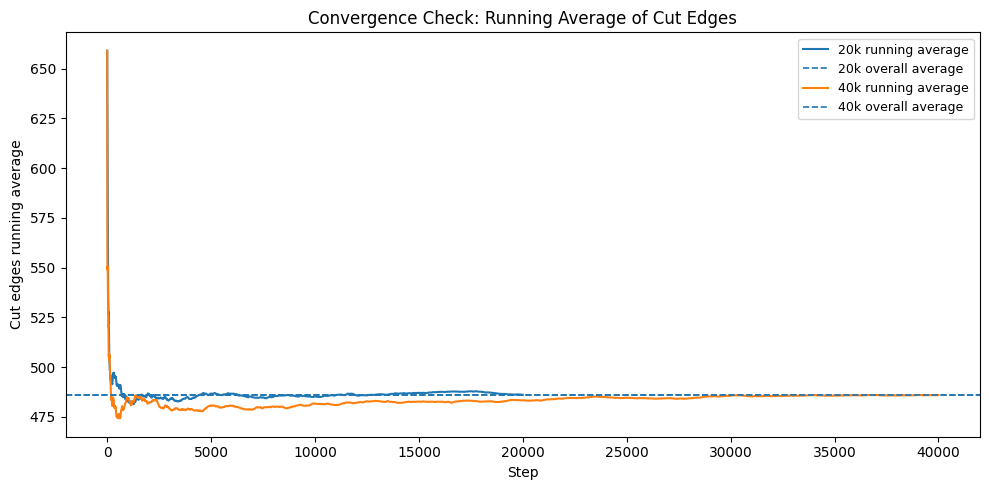

In [7]:
# convergence plot: smooth running average plus flat overall average line
# no block averages and no raw cut-edge trace
def running_average(values):
    values = np.asarray(values, dtype=float)
    return np.cumsum(values) / np.arange(1, len(values) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for results, label in [(results_20k, "20k"), (results_40k, "40k")]:
    values = np.asarray(results["cutedges"], dtype=float)
    ax.plot(running_average(values), linewidth=1.5, label=f"{label} running average")
    ax.axhline(values.mean(), linestyle="--", linewidth=1.2, label=f"{label} overall average")

ax.set_title("Convergence Check: Running Average of Cut Edges")
ax.set_xlabel("Step")
ax.set_ylabel("Cut edges running average")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("convergence_running_average.png", dpi=150)
plt.show()


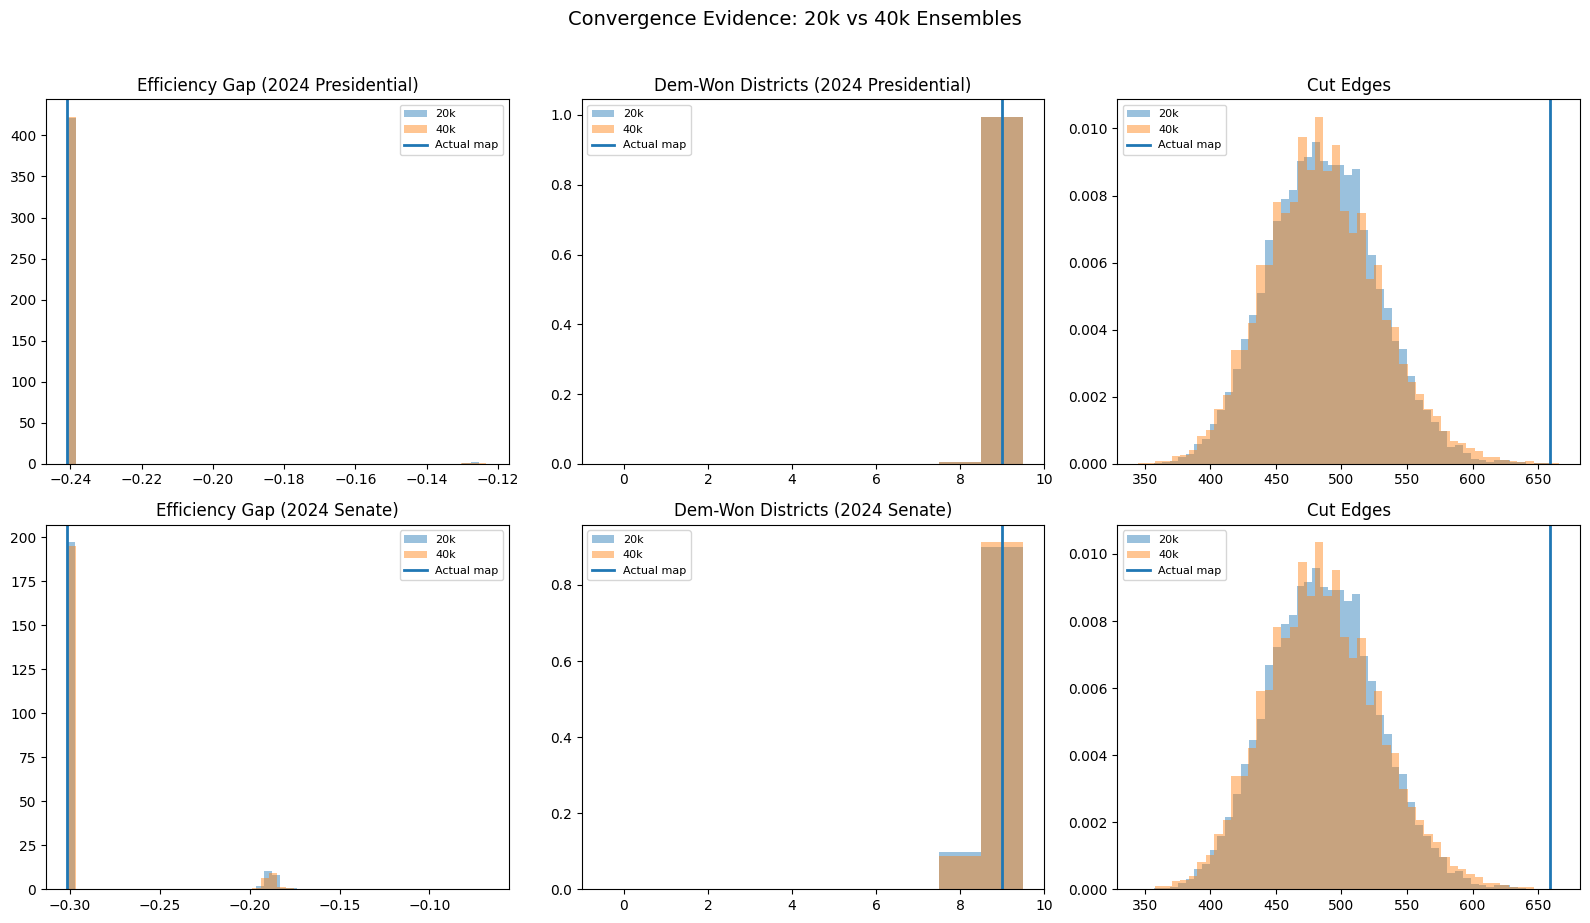

In [8]:
# convergence check: compare 20k and 40k distributions directly
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

comparisons = [
    (axes[0][0], results_20k["PRES24"]["eg"], results_40k["PRES24"]["eg"], actual_eg1, "Efficiency Gap (2024 Presidential)"),
    (axes[0][1], results_20k["PRES24"]["dem_won"], results_40k["PRES24"]["dem_won"], actual_dem_won1, "Dem-Won Districts (2024 Presidential)"),
    (axes[0][2], results_20k["cutedges"], results_40k["cutedges"], actual_cutedges, "Cut Edges"),
    (axes[1][0], results_20k["SEN24"]["eg"], results_40k["SEN24"]["eg"], actual_eg2, "Efficiency Gap (2024 Senate)"),
    (axes[1][1], results_20k["SEN24"]["dem_won"], results_40k["SEN24"]["dem_won"], actual_dem_won2, "Dem-Won Districts (2024 Senate)"),
    (axes[1][2], results_20k["cutedges"], results_40k["cutedges"], actual_cutedges, "Cut Edges")
]

for ax, values_20k, values_40k, actual_value, title in comparisons:
    if "Dem-Won" in title:
        bins = np.arange(0, num_districts + 2) - 0.5
    else:
        bins = 50
    ax.hist(values_20k, bins=bins, alpha=0.45, density=True, label="20k")
    ax.hist(values_40k, bins=bins, alpha=0.45, density=True, label="40k")
    ax.axvline(actual_value, linewidth=2, label="Actual map")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Convergence Evidence: 20k vs 40k Ensembles", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("convergence_20k_vs_40k.png", dpi=150, bbox_inches="tight")
plt.show()


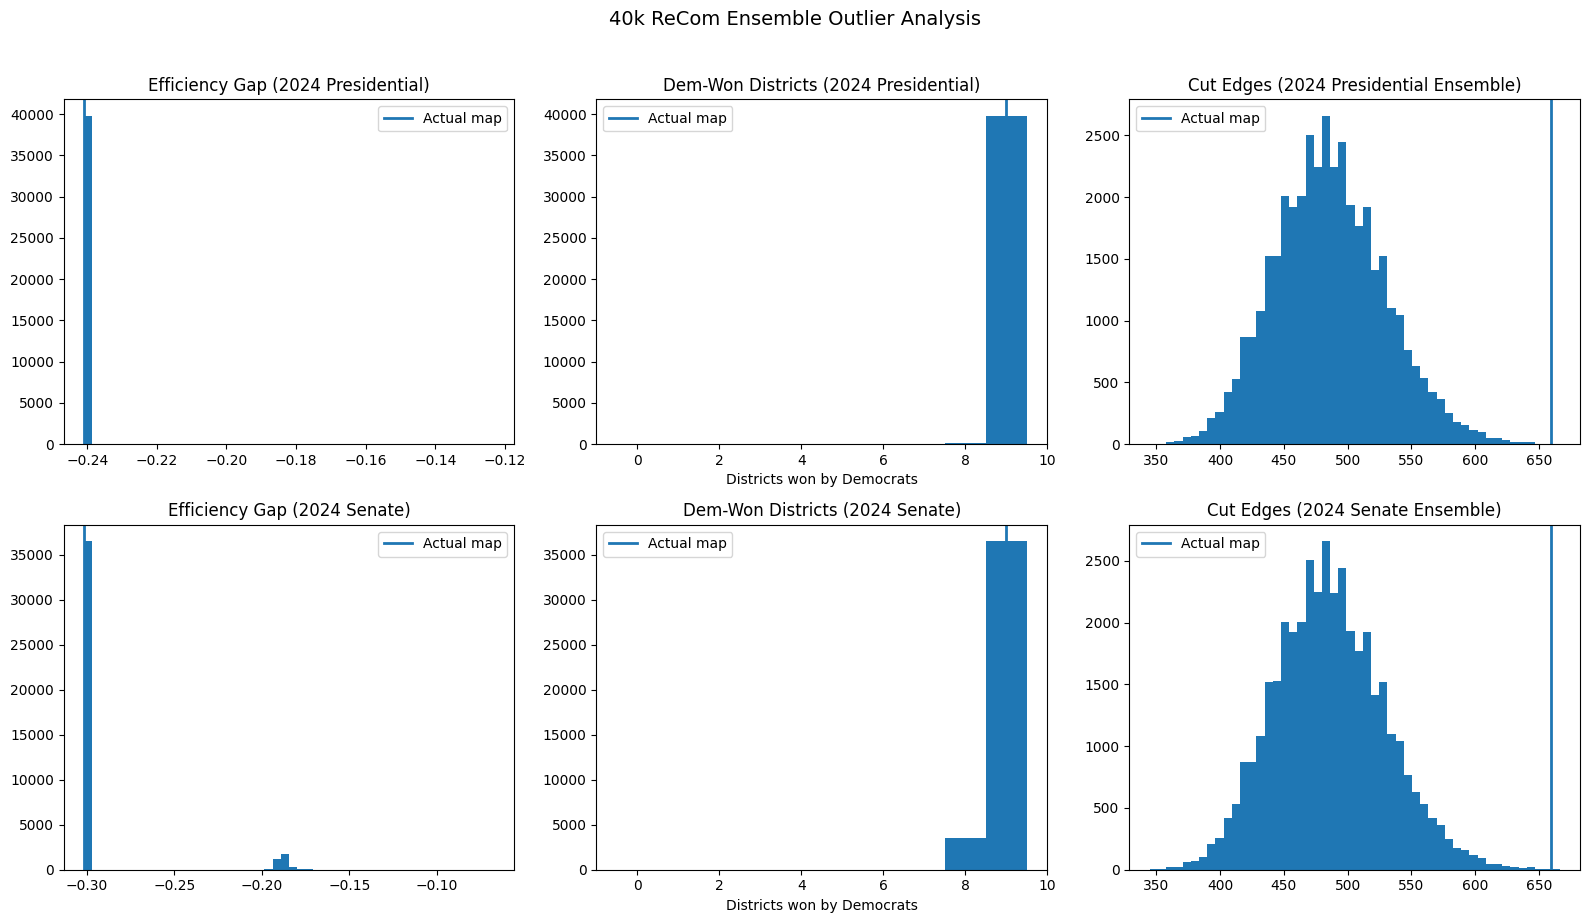

In [9]:
# final outlier histograms using the 40k ensemble
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: 2024 Presidential
axes[0][0].hist(eg1, bins=50)
axes[0][0].axvline(actual_eg1, linewidth=2, label="Actual map")
axes[0][0].set_title("Efficiency Gap (2024 Presidential)")
axes[0][0].legend()

axes[0][1].hist(dem_won1, bins=np.arange(0, num_districts + 2) - 0.5)
axes[0][1].axvline(actual_dem_won1, linewidth=2, label="Actual map")
axes[0][1].set_title("Dem-Won Districts (2024 Presidential)")
axes[0][1].set_xlabel("Districts won by Democrats")
axes[0][1].legend()

axes[0][2].hist(cutedges1, bins=50)
axes[0][2].axvline(actual_cutedges, linewidth=2, label="Actual map")
axes[0][2].set_title("Cut Edges (2024 Presidential Ensemble)")
axes[0][2].legend()

# Row 2: 2024 Senate
axes[1][0].hist(eg2, bins=50)
axes[1][0].axvline(actual_eg2, linewidth=2, label="Actual map")
axes[1][0].set_title("Efficiency Gap (2024 Senate)")
axes[1][0].legend()

axes[1][1].hist(dem_won2, bins=np.arange(0, num_districts + 2) - 0.5)
axes[1][1].axvline(actual_dem_won2, linewidth=2, label="Actual map")
axes[1][1].set_title("Dem-Won Districts (2024 Senate)")
axes[1][1].set_xlabel("Districts won by Democrats")
axes[1][1].legend()

axes[1][2].hist(cutedges2, bins=50)
axes[1][2].axvline(actual_cutedges, linewidth=2, label="Actual map")
axes[1][2].set_title("Cut Edges (2024 Senate Ensemble)")
axes[1][2].legend()

plt.suptitle("40k ReCom Ensemble Outlier Analysis", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("histograms_40k.png", dpi=150, bbox_inches="tight")
plt.show()


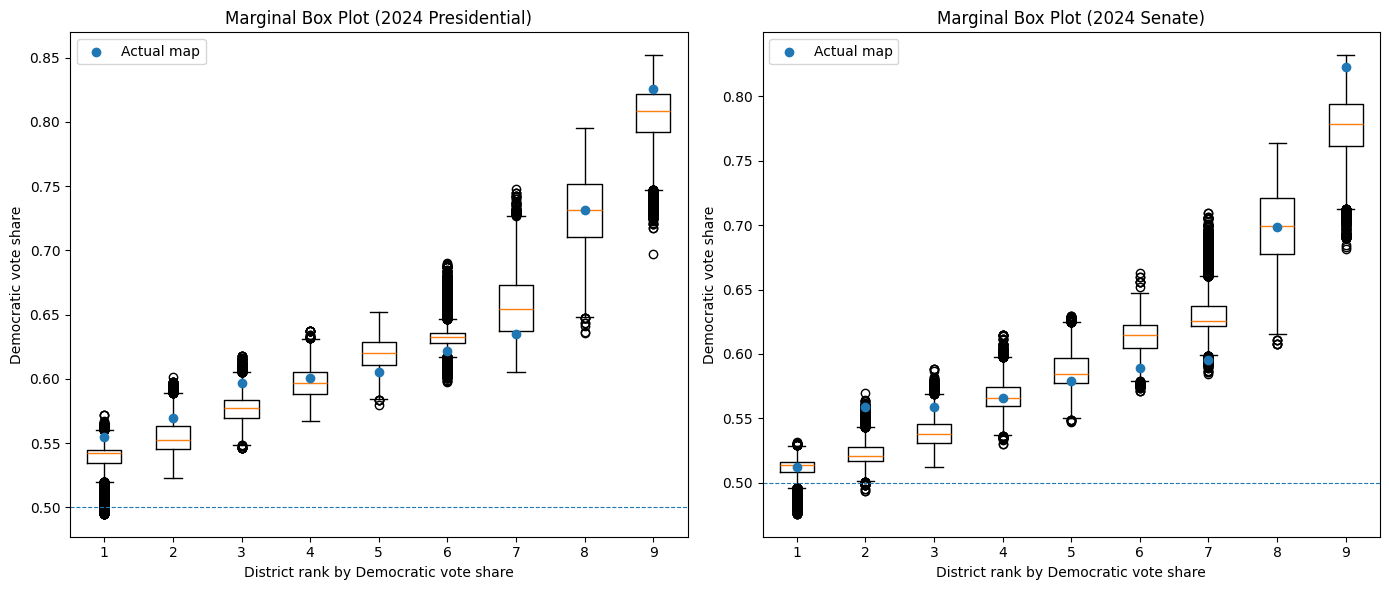

In [10]:
# marginal box plots / signature of gerrymandering using the 40k ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
num_districts = len(actual_margins1)

# 2024 Presidential
box_data1 = [[margins1[step][district] for step in range(len(margins1))] for district in range(num_districts)]
axes[0].boxplot(box_data1, positions=range(1, num_districts + 1))
axes[0].scatter(range(1, num_districts + 1), actual_margins1, zorder=5, label="Actual map")
axes[0].axhline(0.5, linestyle="--", linewidth=0.8)
axes[0].set_title("Marginal Box Plot (2024 Presidential)")
axes[0].set_xlabel("District rank by Democratic vote share")
axes[0].set_ylabel("Democratic vote share")
axes[0].legend()

# 2024 Senate
box_data2 = [[margins2[step][district] for step in range(len(margins2))] for district in range(num_districts)]
axes[1].boxplot(box_data2, positions=range(1, num_districts + 1))
axes[1].scatter(range(1, num_districts + 1), actual_margins2, zorder=5, label="Actual map")
axes[1].axhline(0.5, linestyle="--", linewidth=0.8)
axes[1].set_title("Marginal Box Plot (2024 Senate)")
axes[1].set_xlabel("District rank by Democratic vote share")
axes[1].set_ylabel("Democratic vote share")
axes[1].legend()

plt.tight_layout()
plt.savefig("marginal_boxplots_40k.png", dpi=150)
plt.show()


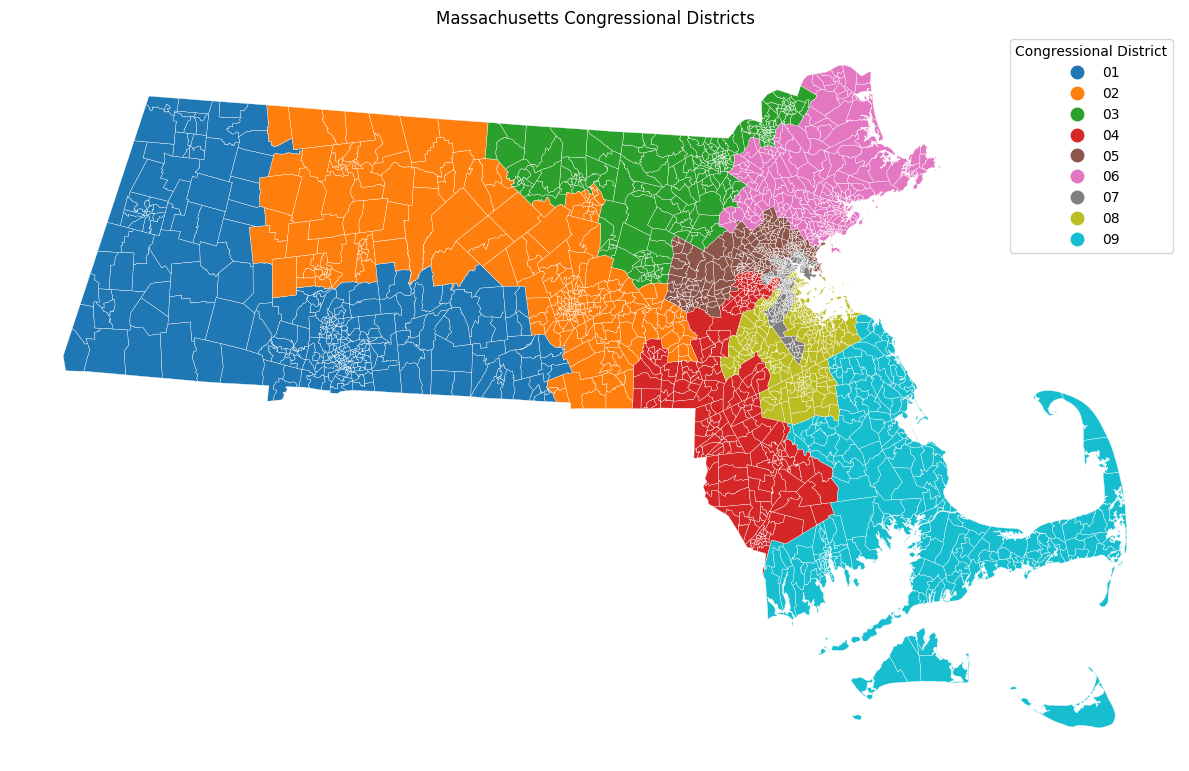

In [11]:
# plot the actual Massachusetts congressional district map
fig, ax = plt.subplots(figsize=(12, 8))
map_df.plot(
    column="CD",
    cmap="tab10",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.25,
    legend_kwds={"title": "Congressional District"},
)
ax.set_title("Massachusetts Congressional Districts")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("ma_districts_map.png", dpi=150)
plt.show()


In [12]:
# compactness of the actual enacted map
pp_scores = polsby_popper(initial_partition)
actual_mean_pp = sum(pp_scores.values()) / len(pp_scores)

print("Polsby-Popper scores for actual MA map:")
for district_label in sorted(pp_scores):
    print(f"  District {district_label}: {pp_scores[district_label]:.4f}")
print(f"  Mean PP: {actual_mean_pp:.4f}")


Polsby-Popper scores for actual MA map:
  District 01: 0.2797
  District 02: 0.2119
  District 03: 0.2237
  District 04: 0.1703
  District 05: 0.1525
  District 06: 0.0421
  District 07: 0.0502
  District 08: 0.0474
  District 09: 0.0085
  Mean PP: 0.1318


In [13]:
# final analysis summary
print("FINAL SUMMARY")
print("graph connected:", nx.is_connected(ma_graph))
print("initial partition contiguous:", contiguous(initial_partition))
print("district count:", len(initial_partition.parts))
print("total population:", int(sum(initial_partition["district population"].values())))
print("20k steps recorded:", len(results_20k["cutedges"]))
print("40k steps recorded:", len(results_40k["cutedges"]))
print("actual cut edges:", actual_cutedges)
print("actual Dem-won districts, PRES24:", actual_dem_won1)
print("actual Dem-won districts, SEN24:", actual_dem_won2)
print("actual EG, PRES24:", round(actual_eg1, 4))
print("actual EG, SEN24:", round(actual_eg2, 4))


FINAL SUMMARY
graph connected: True
initial partition contiguous: True
district count: 9
total population: 7029917
20k steps recorded: 20000
40k steps recorded: 40000
actual cut edges: 659
actual Dem-won districts, PRES24: 9
actual Dem-won districts, SEN24: 9
actual EG, PRES24: -0.2409
actual EG, SEN24: -0.3015
